In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import LinearSVC,SVC
from sklearn.naive_bayes import MultinomialNB


## preprocess reduced data

### relabel data and enumerate words

In [7]:
mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 3,
    "crime": 4,
    
    "science": 5,
    "psychology": 6,
    "history": 7,
    "travel": 8,
    "sports": 9
}
class_number = 10

In [ ]:
mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 2,
    "crime": 2,
    
    "science": 3,
    "psychology": 3,
    "history": 3,
    "travel": 3,
    "sports": 3
}
class_number = 4

In [3]:
dataset = pd.read_csv("reduced.csv")

dataset["label"] = dataset["label"].map(mapped_dict)
dataset = dataset.dropna()


In [4]:
X_train,X_test,y_train,y_test = train_test_split(dataset["text"],dataset["label"],test_size=0.4,stratify=dataset["label"])
X_val,X_test,y_val,y_test = train_test_split(X_test,y_test,test_size=0.5,stratify=y_test)


print("Size of training set: ", len(X_train))
print("Size of validation set: ", len(X_val))
print("Size of test set: ", len(X_test))

print("Training set classes distribution: ")
statistics = y_train.value_counts()
print(statistics)

print("Validation set classes distribution:")
statistics = y_val.value_counts()
print(statistics)

print("Test set classes distribution:")
statistics = y_test.value_counts()
print(statistics)

Size of training set:  13785
Size of validation set:  4595
Size of test set:  4595
Training set classes distribution: 
label
0    4478
1    4247
7    1618
3     883
4     642
6     539
5     493
2     490
8     240
9     155
Name: count, dtype: int64
Validation set classes distribution:
label
0    1493
1    1416
7     540
3     294
4     214
6     179
5     164
2     163
8      80
9      52
Name: count, dtype: int64
Test set classes distribution:
label
0    1492
1    1416
7     539
3     294
4     214
6     180
2     164
5     164
8      80
9      52
Name: count, dtype: int64


### count

In [5]:
count_vectorizer = CountVectorizer()
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)
X_val_counts = count_vectorizer.transform(X_val)

### tfidf

In [ ]:
tfidf = TfidfVectorizer()
X_train_counts = tfidf.fit_transform(X_train)
X_test_counts = tfidf.transform(X_test)
X_val_counts = tfidf.transform(X_val)

# podejście OvR

In [12]:

# create svm classifier for each label
classifiers = []
for i in range(class_number):
    # clf = SVC(kernel='rbf', C=1.0, tol=1e-2,verbose=True, class_weight='balanced', max_iter=2000)
    clf = LinearSVC(C=1.0,tol=1e-2, loss='squared_hinge', class_weight='balanced', max_iter=2000, dual=False)
    clf.fit(X_train_counts, y_train == i)
    classifiers.append(clf)
# evaluate each classifier on validation set
all_scores=np.zeros((X_val_counts.shape[0], class_number))
for i in range(class_number):
        all_scores[:, i] = classifiers[i].decision_function(X_val_counts)

final_predictions = np.argmax(all_scores, axis=1)
print(classification_report(y_val, final_predictions))
print(confusion_matrix(y_val, final_predictions))

c:\Users\aleks\OneDrive\Pulpit\kody\MPUMY\Genre-Classificator\.venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.79      0.84      0.81      1493
           1       0.77      0.83      0.80      1416
           2       0.47      0.34      0.40       163
           3       0.46      0.46      0.46       294
           4       0.56      0.48      0.51       214
           5       0.46      0.34      0.39       164
           6       0.60      0.53      0.56       179
           7       0.71      0.67      0.69       540
           8       0.40      0.28      0.33        80
           9       0.76      0.62      0.68        52

    accuracy                           0.72      4595
   macro avg       0.60      0.54      0.56      4595
weighted avg       0.71      0.72      0.71      4595

[[1256  114    4   43   18    3   11   29   13    2]
 [ 107 1175   13   27   18   23   13   33    7    0]
 [  18   52   56   19    6    4    4    4    0    0]
 [  48   39   15  136   22   11    2   17    1    3]
 [  36   22    9   28  102   

<Axes: >

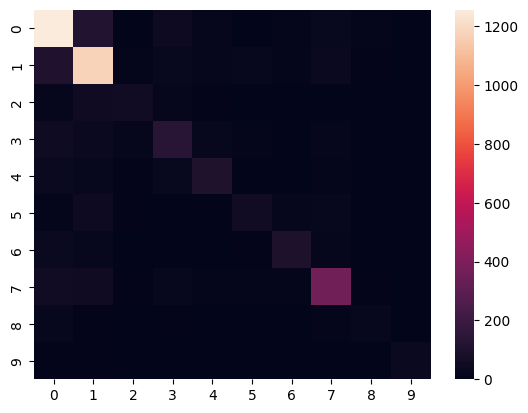

In [ ]:
sns.heatmap(confusion_matrix(y_val, final_predictions),annot=True, fmt='d')

# podejście OvO

In [ ]:
classifiers = {}
for i in range(4):
    for j in range(i+1, 4):
        mask = (y_train == i) | (y_train == j)
        X_train_pair = X_train[mask]
        y_train_pair = (y_train[mask]==i)
        
        clf = LinearSVC(C=1.0,tol=1e-2, loss='squared_hinge',class_weight='balanced', max_iter=2000)
        clf.fit(X_train_pair, y_train_pair)
        classifiers[(i, j)] = clf

confidence_scores=np.zeros((len(X_val), 4))
for (i, j), clf in classifiers.items():
    score = clf.decision_function(X_val)
    confidence_scores[:, i] += score
    confidence_scores[:, j] -= score

finals = np.argmax(confidence_scores, axis=1)
print(classification_report(y_val, finals))
print(confusion_matrix(y_val, finals))
    